# 📊 Customer Churn Classification & Exploratory Data Analysis
โครงการนี้มุ่งเน้นการวิเคราะห์ปัจจัยที่มีผลต่อการยกเลิกใช้บริการของลูกค้า (Bank Customer Churn) และสร้างโมเดล Machine Learning เพื่อทำนายพฤติกรรมการลาออกของลูกค้าด้วย **Random Forest Classifier** พร้อมการแสดงผลด้วย **Seaborn** และ **Matplotlib**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# ตั้งค่า Styling สำหรับ Seaborn & Matplotlib
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.size'] = 11
plt.rcParams['figure.titlesize'] = 14
%matplotlib inline

## 1️⃣ Step 1: Data Loading & Initial Exploration
โหลดชุดข้อมูล `ChurnModelling.csv` และตรวจสอบโครงสร้างข้อมูลเบื้องต้น

In [2]:
# โหลดข้อมูล
df = pd.read_csv('ChurnModelling.csv')

print(f"ขนาดของข้อมูล: {df.shape[0]} แถว, {df.shape[1]} คอลัมน์")
df.head()

ขนาดของข้อมูล: 10000 แถว, 14 คอลัมน์


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
# ตรวจสอบประเภทข้อมูลและค่าที่สูญหาย (Missing Values)
print("--- ข้อมูล Info ---")
df.info()
print("\n--- เช็คค่า Missing Values ---")
print(df.isna().sum())

--- ข้อมูล Info ---
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.2 MB

--- เช็คค่า Missing Values ---
RowNumber          0
CustomerId         0
Surname        

In [4]:
# สถิติเชิงพรรณนา (Descriptive Statistics)
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


## 2️⃣ Step 2: Exploratory Data Analysis (EDA) ด้วย Seaborn
ทำการวิเคราะห์สำรวจข้อมูลเชิงลึก (EDA) เพื่อค้นหาความสัมพันธ์และปัจจัยสำคัญที่มีผลต่อการยกเลิกบริการ (Exited)

### 2.1 สัดส่วนการยกเลิกบริการของลูกค้า (Target Distribution)

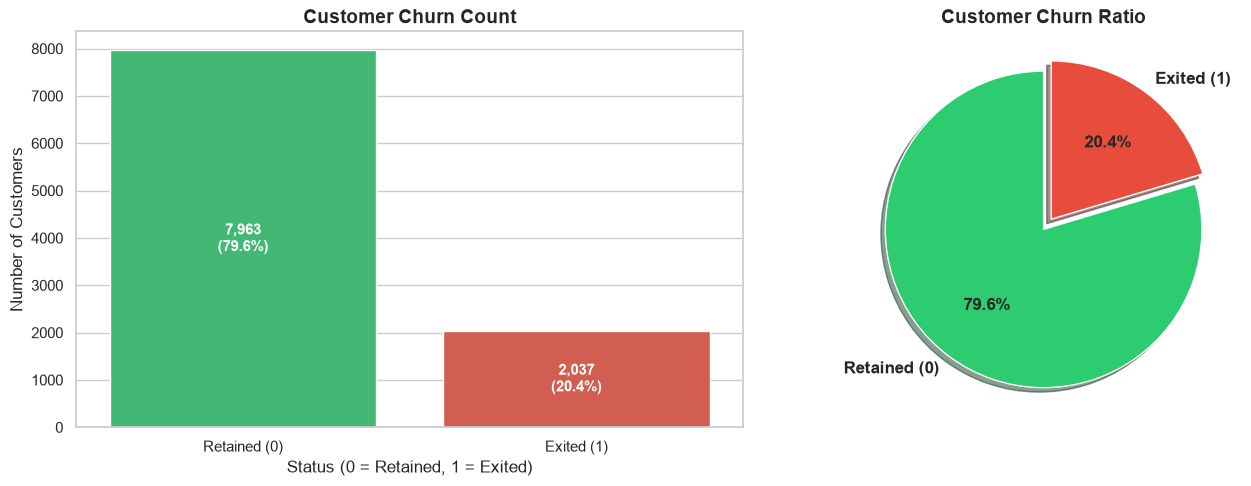

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
palette = ['#2ecc71', '#e74c3c']

# Countplot
sns.countplot(x='Exited', data=df, ax=axes[0], palette=palette, hue='Exited', legend=False)
axes[0].set_title('Customer Churn Count', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Status (0 = Retained, 1 = Exited)')
axes[0].set_ylabel('Number of Customers')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Retained (0)', 'Exited (1)'])

for p in axes[0].patches:
    height = p.get_height()
    axes[0].annotate(f'{int(height):,}\n({height/len(df)*100:.1f}%)',
                     (p.get_x() + p.get_width() / 2., height / 2),
                     ha='center', va='center', fontsize=11, color='white', fontweight='bold')

# Pie chart
exited_counts = df['Exited'].value_counts()
axes[1].pie(exited_counts, labels=['Retained (0)', 'Exited (1)'], autopct='%1.1f%%',
            startangle=90, colors=palette, explode=(0, 0.08), shadow=True,
            textprops={'fontsize': 12, 'fontweight': 'bold'})
axes[1].set_title('Customer Churn Ratio', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

### 2.2 อัตราการยกเลิกบริการตามปัจจัยหมวดหมู่ (Categorical Features vs Churn)
วิเคราะห์ผลกระทบของประเทศ (`Geography`), เพศ (`Gender`), จำนวนผลิตภัณฑ์ (`NumOfProducts`), และสถานะการใช้งาน (`IsActiveMember`)

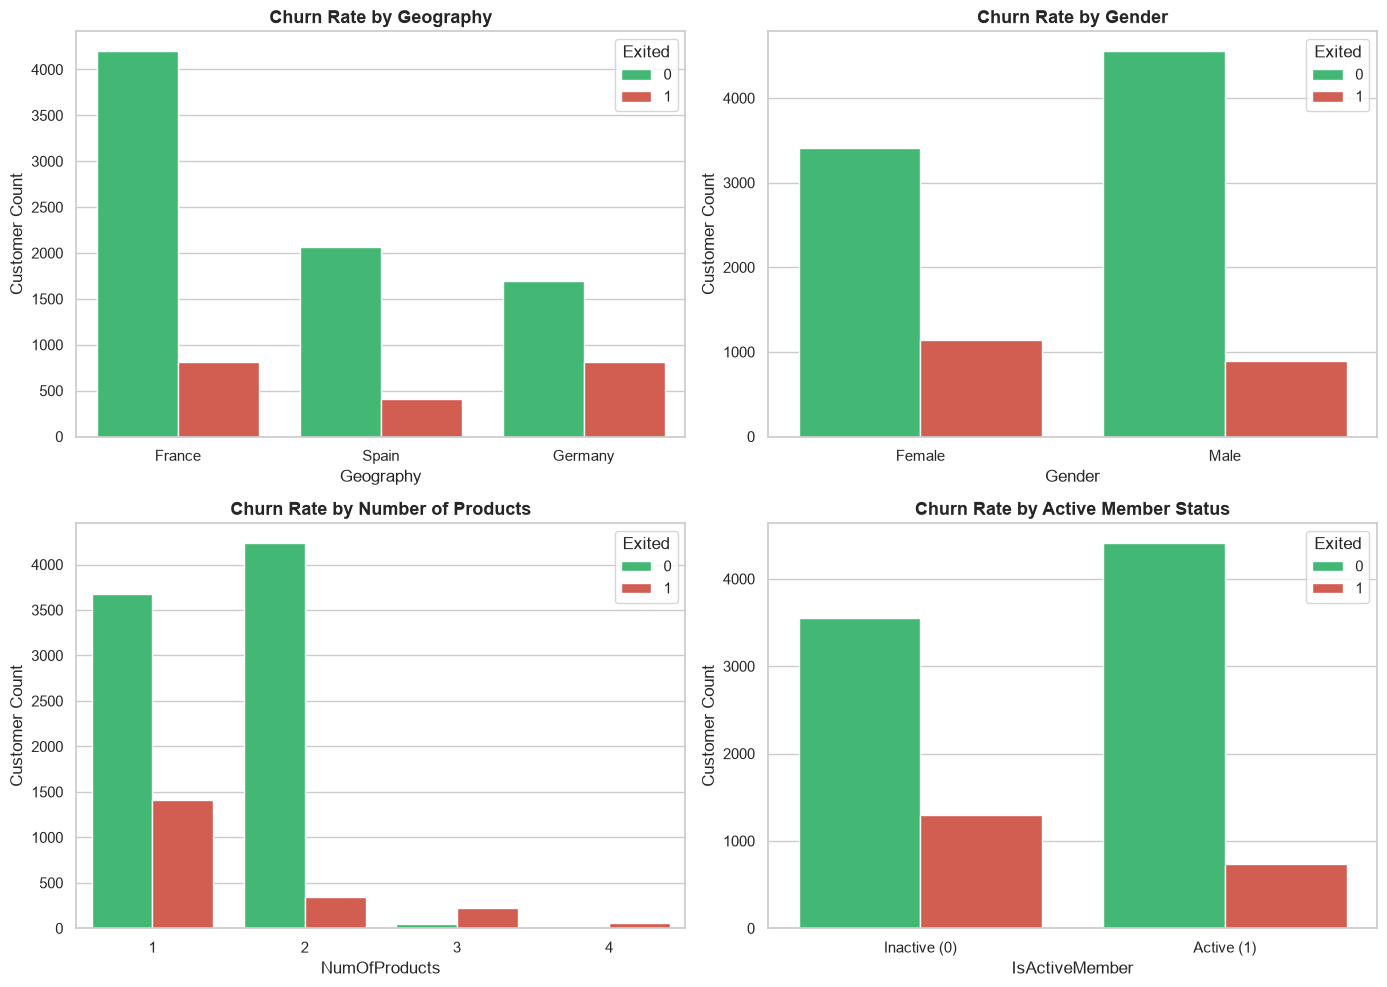

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(x='Geography', hue='Exited', data=df, ax=axes[0, 0], palette=palette)
axes[0, 0].set_title('Churn Rate by Geography', fontsize=13, fontweight='bold')
axes[0, 0].set_ylabel('Customer Count')

sns.countplot(x='Gender', hue='Exited', data=df, ax=axes[0, 1], palette=palette)
axes[0, 1].set_title('Churn Rate by Gender', fontsize=13, fontweight='bold')
axes[0, 1].set_ylabel('Customer Count')

sns.countplot(x='NumOfProducts', hue='Exited', data=df, ax=axes[1, 0], palette=palette)
axes[1, 0].set_title('Churn Rate by Number of Products', fontsize=13, fontweight='bold')
axes[1, 0].set_ylabel('Customer Count')

sns.countplot(x='IsActiveMember', hue='Exited', data=df, ax=axes[1, 1], palette=palette)
axes[1, 1].set_title('Churn Rate by Active Member Status', fontsize=13, fontweight='bold')
axes[1, 1].set_ylabel('Customer Count')
axes[1, 1].set_xticks([0, 1])
axes[1, 1].set_xticklabels(['Inactive (0)', 'Active (1)'])

plt.tight_layout()
plt.show()

### 2.3 การกระจายตัวของข้อมูลเชิงตัวเลข (Numerical Features Distribution)
เปรียบเทียบการกระจายตัวของอายุ (`Age`), ยอดเงินในบัญชี (`Balance`), คะแนนเครดิต (`CreditScore`), และประมาณการเงินเดือน (`EstimatedSalary`)

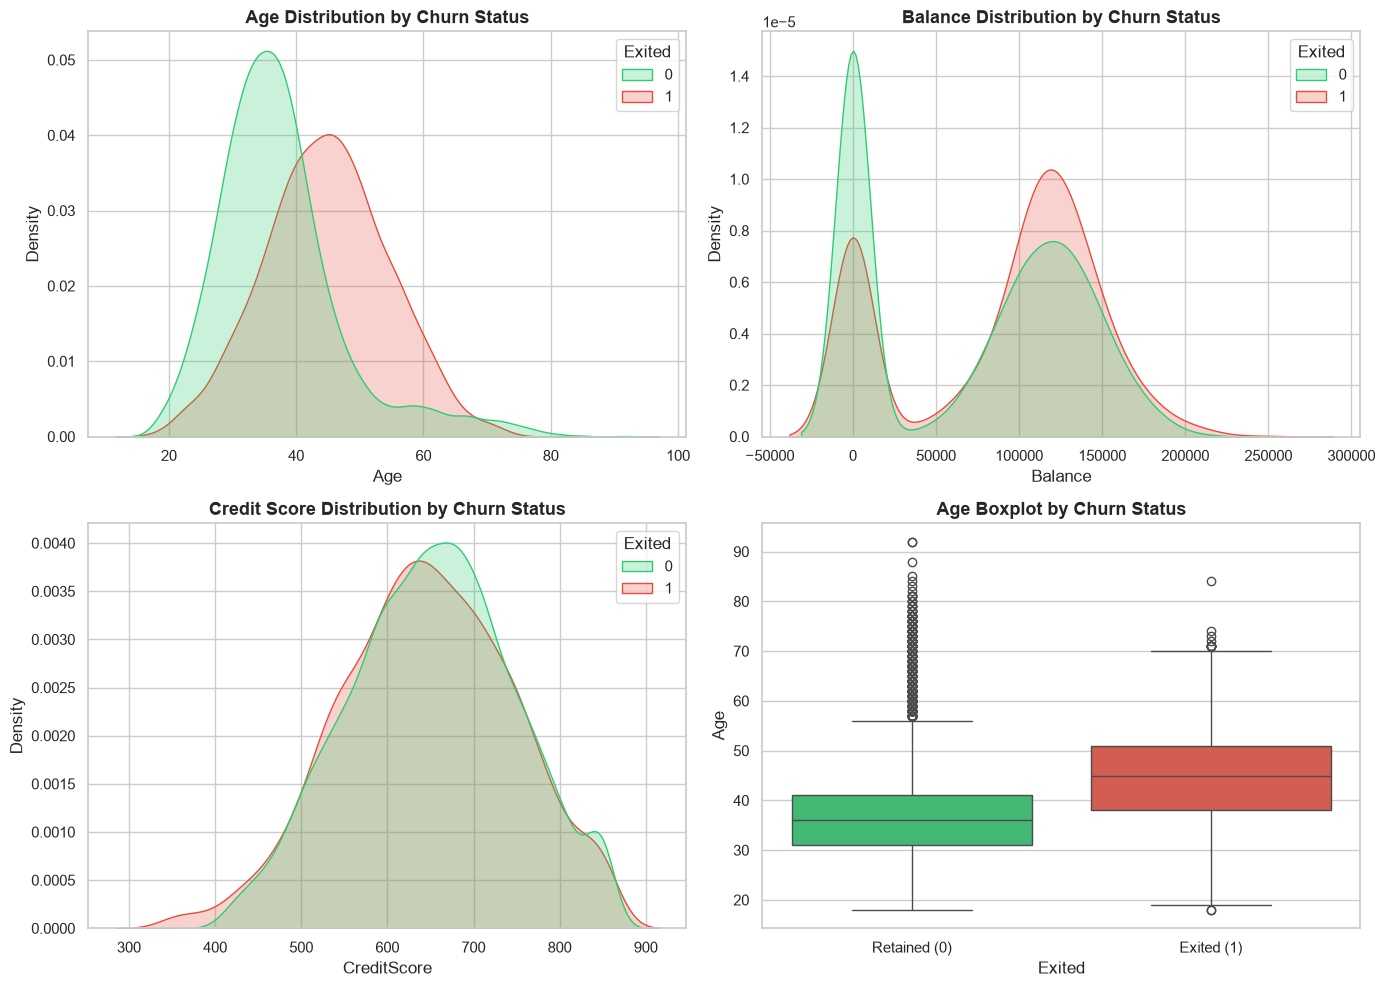

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.kdeplot(data=df, x='Age', hue='Exited', fill=True, ax=axes[0, 0], palette=palette, common_norm=False)
axes[0, 0].set_title('Age Distribution by Churn Status', fontsize=13, fontweight='bold')

sns.kdeplot(data=df, x='Balance', hue='Exited', fill=True, ax=axes[0, 1], palette=palette, common_norm=False)
axes[0, 1].set_title('Balance Distribution by Churn Status', fontsize=13, fontweight='bold')

sns.kdeplot(data=df, x='CreditScore', hue='Exited', fill=True, ax=axes[1, 0], palette=palette, common_norm=False)
axes[1, 0].set_title('Credit Score Distribution by Churn Status', fontsize=13, fontweight='bold')

sns.boxplot(x='Exited', y='Age', data=df, ax=axes[1, 1], palette=palette, hue='Exited', legend=False)
axes[1, 1].set_title('Age Boxplot by Churn Status', fontsize=13, fontweight='bold')
axes[1, 1].set_xticks([0, 1])
axes[1, 1].set_xticklabels(['Retained (0)', 'Exited (1)'])

plt.tight_layout()
plt.show()

## 3️⃣ Step 3: Data Cleaning & Feature Selection
คอลัมน์ `RowNumber`, `CustomerId`, และ `Surname` เป็นข้อมูลระบุตัวตนเฉพาะบุคคล ไม่ส่งผลต่อการพิจารณาการเลิกใช้บริการ จึงทำการลบออก

In [8]:
df_cleaned = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])
print("คอลัมน์ที่เหลืออยู่สำหรับนำไปใช้ในโมเดล:")
print(df_cleaned.columns.tolist())

คอลัมน์ที่เหลืออยู่สำหรับนำไปใช้ในโมเดล:
['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


## 4️⃣ Step 4: Encoding Categorical Features
แปลงตัวแปรประเภทข้อความ (`Geography` และ `Gender`) ให้เป็นตัวเลขด้วย **One-Hot Encoding** (`pd.get_dummies`)

In [9]:
df_encoded = pd.get_dummies(df_cleaned, columns=['Geography', 'Gender'], drop_first=True)
df_encoded.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


### 2.4 เมทริกซ์ความสัมพันธ์ (Correlation Matrix Heatmap)

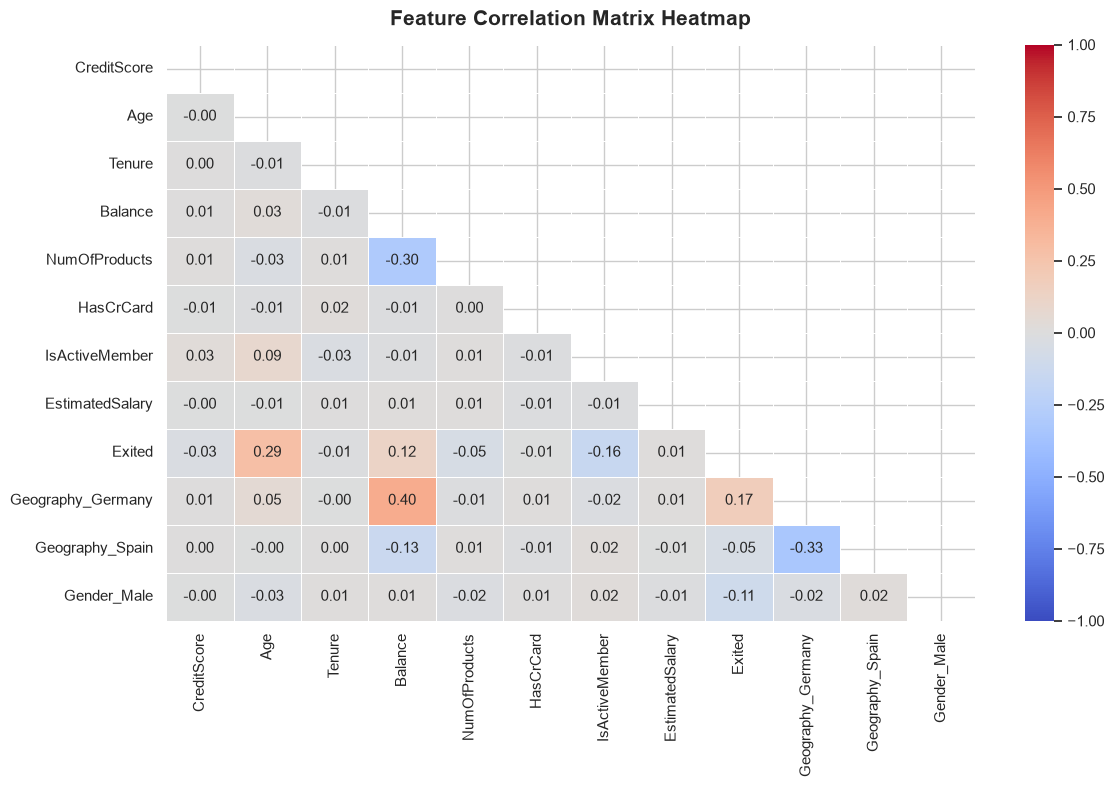

In [10]:
plt.figure(figsize=(12, 8))
corr = df_encoded.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, mask=mask, linewidths=0.5)
plt.title('Feature Correlation Matrix Heatmap', fontsize=15, fontweight='bold', pad=14)
plt.tight_layout()
plt.show()

## 5️⃣ Step 5: Train-Test Split & Feature Scaling
แบ่งข้อมูลเป็นชุดฝึกสอน (Train Set 80%) และชุดทดสอบ (Test Set 20%) พร้อมทำการปรับสเกลข้อมูลด้วย `StandardScaler`

In [11]:
# แยก X (Features) และ y (Target)
X = df_encoded.drop(columns=['Exited'])
y = df_encoded['Exited']

# แบ่ง Train (80%) และ Test (20%) แบบ Stratified
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"จำนวนข้อมูล X_train: {X_train_scaled.shape}")
print(f"จำนวนข้อมูล X_test:  {X_test_scaled.shape}")

จำนวนข้อมูล X_train: (8000, 11)
จำนวนข้อมูล X_test:  (2000, 11)


## 6️⃣ Step 6: Model Training & Model Evaluation
สร้างโมเดล **Random Forest Classifier** ประเมินประสิทธิภาพ พร้อมแสดง Confusion Matrix และ Feature Importance ด้วย Seaborn

In [12]:
# 1. สร้างและฝึกสอนโมเดล Random Forest
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

# 2. ทำนายผลกับชุดข้อมูลทดสอบ
y_pred = model.predict(X_test_scaled)

# 3. ประเมินผลลัพธ์
acc = accuracy_score(y_test, y_pred)
print(f"--- ความแม่นยำ (Accuracy): {acc:.4f} ({acc*100:.2f}%) ---\n")
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

--- ความแม่นยำ (Accuracy): 0.8630 (86.30%) ---

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1593
           1       0.78      0.46      0.58       407

    accuracy                           0.86      2000
   macro avg       0.83      0.71      0.75      2000
weighted avg       0.85      0.86      0.85      2000



### 6.1 แสดง Confusion Matrix ด้วย Seaborn Heatmap

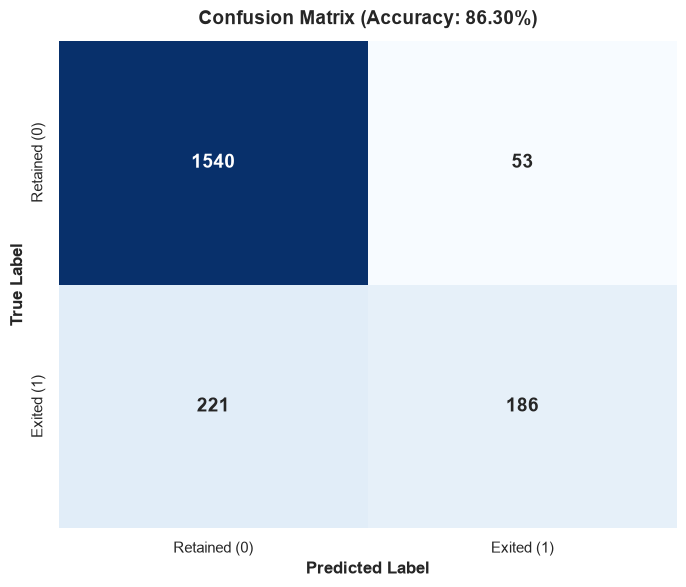

In [13]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Retained (0)', 'Exited (1)'],
            yticklabels=['Retained (0)', 'Exited (1)'],
            annot_kws={'size': 14, 'weight': 'bold'})
plt.title(f'Confusion Matrix (Accuracy: {acc*100:.2f}%)', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### 6.2 ความสำคัญของตัวแปรในการทำนาย (Feature Importance Plot)

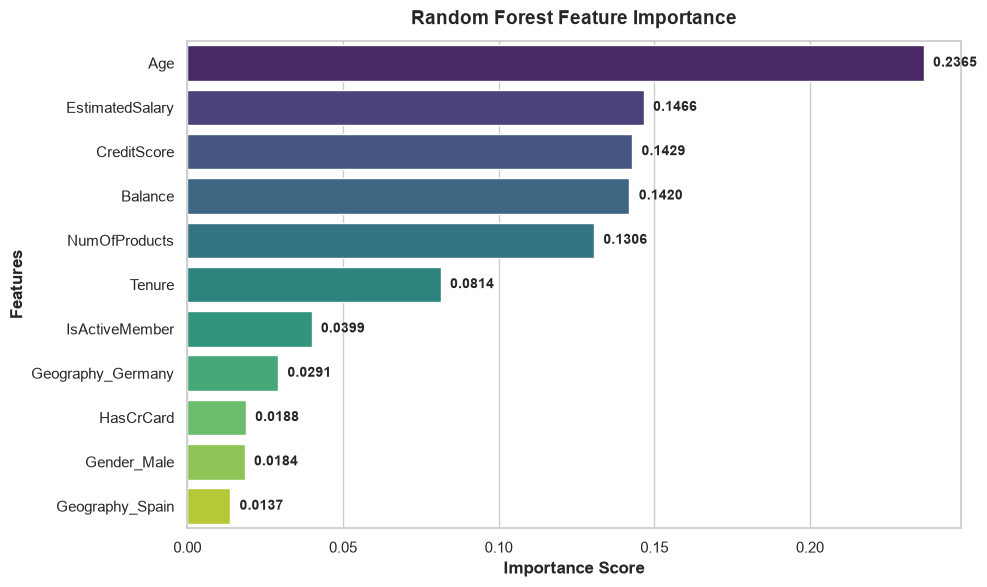

In [14]:
importances = model.feature_importances_
feature_names = X.columns
feat_imp = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_imp, palette='viridis', hue='Feature', legend=False)
plt.title('Random Forest Feature Importance', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Importance Score', fontsize=12, fontweight='bold')
plt.ylabel('Features', fontsize=12, fontweight='bold')

for i, v in enumerate(feat_imp['Importance']):
    plt.text(v + 0.003, i, f"{v:.4f}", va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()